# K-Means: k Selection and Dataset Comparison

This notebook uses the from-scratch `KMeans` in `models/kmeans.py` to: 
1) Compare different values of `k` (number of clusters) and compute clustering metrics (ARI, AMI, silhouette, purity, inertia).
2) Compare the performance of KMeans on `results/fires_engineered_features.csv` (engineered/scaled) vs `results/fires_merged_all_features.csv` (original) using the same k-grid.

Notes: KMeans is distance-based and sensitive to feature scaling. We will scale the original dataset numeric features (StandardScaler) to make the comparison fair versus the engineered features (which are scaled). 

In [1]:
# Imports and setup
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import FIRES_ENGINEERED_UNSUPERVISED, FIRES_MERGED_UNSUPERVISED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
                             homogeneity_score, completeness_score, silhouette_score,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

# Import custom KMeans
from models.kmeans import KMeans

# Dunn index function (min inter-cluster distance / max intra-cluster diameter)
def compute_dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    # remove noise labels (-1) if present
    unique_clusters = unique_clusters[unique_clusters != -1] if len(unique_clusters) > 0 else unique_clusters
    if len(unique_clusters) < 2:
        return np.nan

    # compute cluster diameters (max pairwise distance within each cluster)
    max_diameter = 0.0
    for c in unique_clusters:
        pts = X[labels == c]
        if len(pts) <= 1:
            continue
        # pairwise distances (we can use numpy broadcasting)
        dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=2)
        diam = dists.max()
        if diam > max_diameter:
            max_diameter = diam

    if max_diameter == 0:
        return np.nan

    # compute min inter-cluster distance
    min_inter_dist = np.inf
    for i, c1 in enumerate(unique_clusters):
        for c2 in unique_clusters[i+1:]:
            pts1 = X[labels == c1]
            pts2 = X[labels == c2]
            # min distance between any two points from different clusters
            inter_dists = np.linalg.norm(pts1[:, None, :] - pts2[None, :, :], axis=2)
            min_d = inter_dists.min()
            if min_d < min_inter_dist:
                min_inter_dist = min_d

    return min_inter_dist / max_diameter

In [2]:
# Load datasets
df_eng = pd.read_csv(FIRES_ENGINEERED_UNSUPERVISED)
df_orig = pd.read_csv(FIRES_MERGED_UNSUPERVISED)

# Add class column to engineered dataset from original (same row order)
df_eng['class'] = df_orig['class'].values

print('Engineered:', df_eng.shape)
print(df_eng['class'].value_counts())
print('Original:', df_orig.shape)
print(df_orig['class'].value_counts())

Engineered: (28432, 8)
class
1    14216
0    14216
Name: count, dtype: int64
Original: (28432, 44)
class
1    14216
0    14216
Name: count, dtype: int64


## Prepare Features
- Engineered: already scaled & numeric features used.
- Original: select numeric-only columns, fill missing values, and scale features with StandardScaler for fair comparison.

In [3]:
# ENGINEERED dataset
X_eng = df_eng.drop(['longitude','latitude','class'], axis=1).values
y_eng = df_eng['class'].values

# ORIGINAL dataset - numeric only
X_orig_full = df_orig.drop(['longitude','latitude','class'], axis=1)
non_numeric = X_orig_full.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print('Dropping non-numeric columns from original:', non_numeric)
    X_orig_full = X_orig_full.select_dtypes(include=[np.number])

# Fill missing values if any
if X_orig_full.isnull().sum().sum() > 0:
    X_orig_full = X_orig_full.fillna(X_orig_full.mean())

scaler = StandardScaler()
X_orig_scaled = scaler.fit_transform(X_orig_full.values)
y_orig = df_orig['class'].values

print('X_eng shape:', X_eng.shape)
print('X_orig_scaled shape:', X_orig_scaled.shape)

X_eng shape: (28432, 5)
X_orig_scaled shape: (28432, 41)


## Evaluate K values with Custom KMeans
We will test a range of k values and compute clustering metrics per k for each dataset.

In [4]:
# Memory-efficient Dunn index with sampling for large clusters
def compute_dunn_index_sampled(X, labels, max_samples=500):
    unique_clusters = np.unique(labels)
    unique_clusters = unique_clusters[unique_clusters != -1] if len(unique_clusters) > 0 else unique_clusters
    if len(unique_clusters) < 2:
        return np.nan

    rng = np.random.default_rng(42)
    
    # compute cluster diameters with sampling
    max_diameter = 0.0
    for c in unique_clusters:
        pts = X[labels == c]
        if len(pts) <= 1:
            continue
        # Sample if too large
        if len(pts) > max_samples:
            idx = rng.choice(len(pts), max_samples, replace=False)
            pts = pts[idx]
        # Compute pairwise distances iteratively to save memory
        diam = 0.0
        for i in range(len(pts)):
            dists = np.linalg.norm(pts[i] - pts[i+1:], axis=1)
            if len(dists) > 0 and dists.max() > diam:
                diam = dists.max()
        if diam > max_diameter:
            max_diameter = diam

    if max_diameter == 0:
        return np.nan

    # compute min inter-cluster distance with sampling
    min_inter_dist = np.inf
    for i, c1 in enumerate(unique_clusters):
        for c2 in unique_clusters[i+1:]:
            pts1 = X[labels == c1]
            pts2 = X[labels == c2]
            # Sample if too large
            if len(pts1) > max_samples:
                idx = rng.choice(len(pts1), max_samples, replace=False)
                pts1 = pts1[idx]
            if len(pts2) > max_samples:
                idx = rng.choice(len(pts2), max_samples, replace=False)
                pts2 = pts2[idx]
            # Compute min distance iteratively
            for p1 in pts1:
                dists = np.linalg.norm(p1 - pts2, axis=1)
                min_d = dists.min()
                if min_d < min_inter_dist:
                    min_inter_dist = min_d
                    if min_inter_dist == 0:
                        break
            if min_inter_dist == 0:
                break
        if min_inter_dist == 0:
            break

    return min_inter_dist / max_diameter

def evaluate_k_grid(X, y, k_values, init='k-means++', random_state=42):
    results = []
    for k in k_values:
        model = KMeans(n_clusters=k, init=init, random_state=random_state)
        model.fit(X)
        labels = model.labels_
        inertia = float(model.inertia_) if hasattr(model, 'inertia_') else np.nan

        ari = adjusted_rand_score(y, labels)
        ami = adjusted_mutual_info_score(y, labels, average_method='arithmetic')
        hom = homogeneity_score(y, labels)
        comp = completeness_score(y, labels)

        # WCSS (Within-Cluster Sum of Squares) -> inertia from our KMeans implementation
        wcss = inertia

        # Purity: cluster-wise majority/ total (moved before DBI/CH to define unique_clusters first)
        unique_clusters = np.unique(labels)

        # Davies-Bouldin Index and Calinski-Harabasz (only if >=2 clusters)
        try:
            if len(unique_clusters) >= 2:
                dbi = davies_bouldin_score(X, labels)
                ch = calinski_harabasz_score(X, labels)
            else:
                dbi = np.nan
                ch = np.nan
        except Exception:
            dbi = np.nan
            ch = np.nan

        # Dunn index (using memory-efficient sampled version)
        dunn = compute_dunn_index_sampled(X, labels)
        cluster_purities = []
        for c in unique_clusters:
            members = y[labels == c]
            if len(members) == 0:
                cluster_purities.append(0)
            else:
                cluster_purities.append(np.bincount(members.astype(int)).max())
        purity = np.sum(cluster_purities) / len(labels)

        try:
            if len(unique_clusters) >= 2:
                sil = silhouette_score(X, labels, metric='euclidean')
            else:
                sil = np.nan
        except Exception:
            sil = np.nan

        results.append({
            'k': k,
            'ARI': ari,
            'AMI': ami,
            'homogeneity': hom,
            'completeness': comp,
            'purity': purity,
            'silhouette': sil,
            'inertia': inertia,
            'WCSS': wcss,
            'DBI': dbi,
            'CH': ch,
            'Dunn': dunn
        })
    return pd.DataFrame(results)

k_values = [2, 3, 4, 5, 6, 8, 10]

print('Running K grid on Engineered dataset...')
results_eng = evaluate_k_grid(X_eng, y_eng, k_values)
print('Engineered results:')
display(results_eng)

print('Running K grid on Original (scaled) dataset...')
results_orig = evaluate_k_grid(X_orig_scaled, y_orig, k_values)
print('Original results:')
display(results_orig)

Running K grid on Engineered dataset...
Engineered results:


,k,ARI,AMI,homogeneity,completeness,purity,silhouette,inertia,WCSS,DBI,CH,Dunn
0,2,0.260496,0.238931,0.229697,0.248981,0.755205,0.303499,113240.267860,113240.267860,1.332686,7260.561992,0.007692
1,3,0.174168,0.163137,0.210839,0.133082,0.740574,0.263010,102109.885920,102109.885920,1.630615,5575.291182,0.001444
2,4,0.114189,0.125469,0.185466,0.094853,0.738675,0.277308,93605.670371,93605.670371,1.432998,4915.309358,0.001472
3,5,0.135391,0.109129,0.162015,0.082343,0.714477,0.380346,66558.737769,66558.737769,0.952525,8072.257503,0.000739
4,6,0.184483,0.178466,0.297918,0.127452,0.752532,0.354358,60381.611776,60381.611776,1.010126,7699.802623,0.000501
5,8,0.110316,0.152430,0.284400,0.104192,0.754150,0.384222,46353.231352,46353.231352,0.956596,8392.731555,0.000554
6,10,0.114307,0.159068,0.307860,0.107329,0.766636,0.400642,23928.635310,23928.635310,0.820575,15603.675047,0.000670


Running K grid on Original (scaled) dataset...
Original results:


,k,ARI,AMI,homogeneity,completeness,purity,silhouette,inertia,WCSS,DBI,CH,Dunn
0,2,0.023505,0.018362,0.018030,0.018760,0.576709,0.257283,908159.220016,908159.220016,1.767779,7172.645095,0.095193
1,3,0.006013,0.005703,0.007307,0.004730,0.544844,0.290857,730473.438794,730473.438794,1.615445,7916.169921,0.061981
2,4,0.022956,0.051068,0.072444,0.039493,0.588175,0.346058,610948.751124,610948.751124,1.442458,8163.556935,0.057435
3,5,0.029049,0.060612,0.093735,0.044853,0.625598,0.359963,546326.187113,546326.187113,1.502811,7687.277507,0.052291
4,6,0.039263,0.070578,0.120648,0.049947,0.656690,0.292788,517469.663905,517469.663905,1.581406,6809.569659,0.020424
5,8,0.027260,0.067175,0.124666,0.046058,0.657252,0.287689,479825.240073,479825.240073,1.554144,5563.779874,0.019777
6,10,0.032106,0.072101,0.142100,0.048402,0.667874,0.310604,427367.697730,427367.697730,1.571964,5245.841140,0.006650


## Plot metrics vs K and compare datasets
We'll plot ARI, AMI, Silhouette & Purity for both datasets across the tested k values, plus inertia curves.

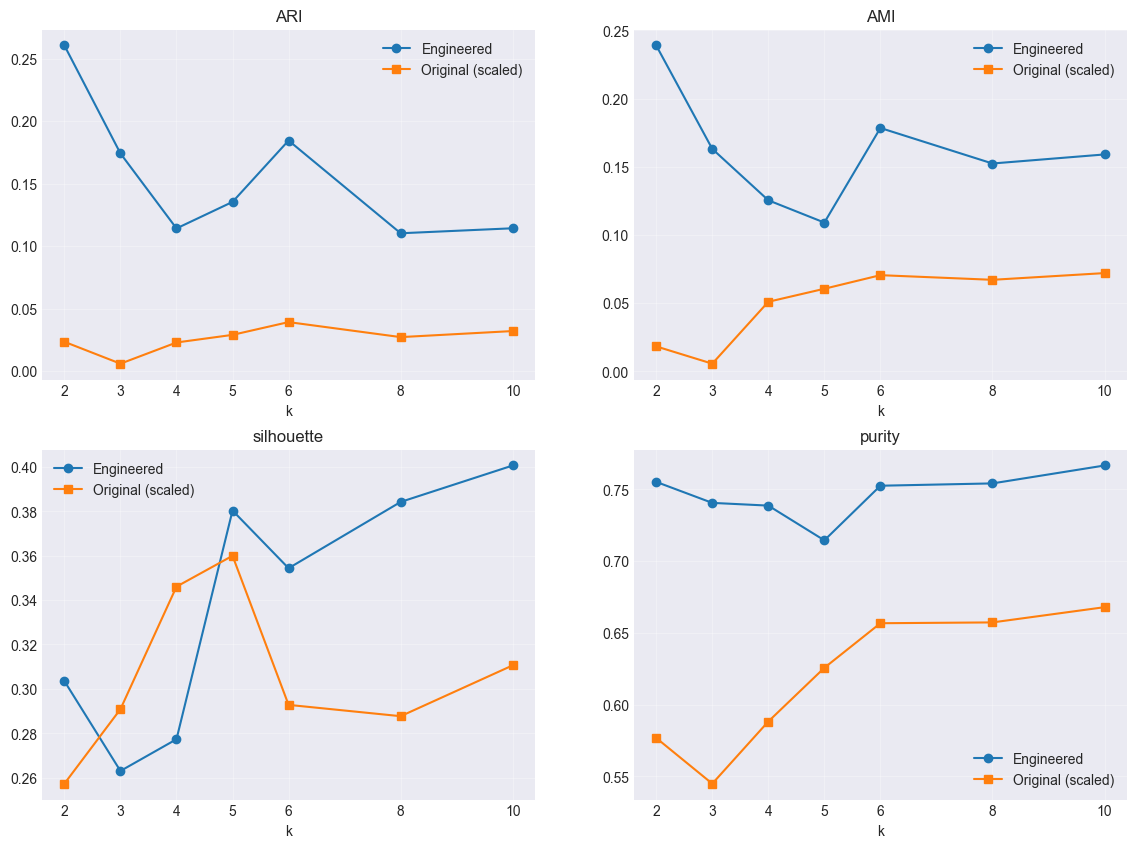

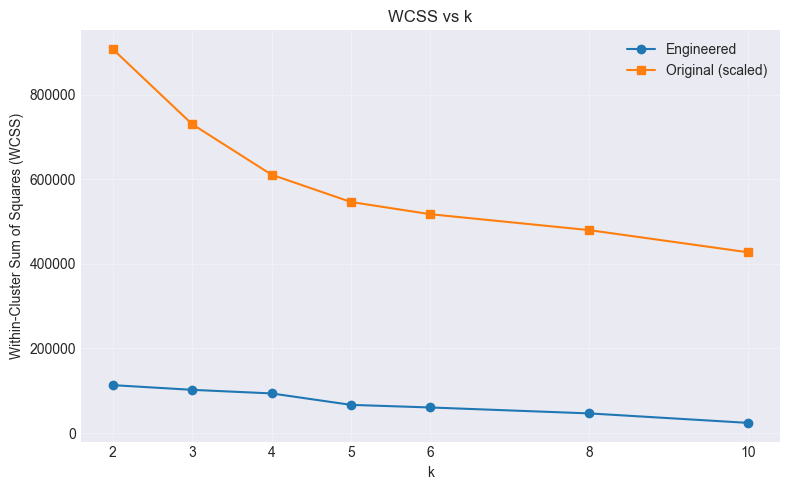

In [5]:
metrics_to_plot = ['ARI','AMI','silhouette','purity','WCSS','DBI','CH','Dunn']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, m in enumerate(metrics_to_plot[:4]):
    axes[i].plot(results_eng['k'], results_eng[m], marker='o', label='Engineered')
    axes[i].plot(results_orig['k'], results_orig[m], marker='s', label='Original (scaled)')
    axes[i].set_title(m)
    axes[i].set_xlabel('k')
    axes[i].set_xticks(k_values)
    axes[i].legend()
    axes[i].grid(alpha=0.3)

# WCSS / Inertia plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_eng['k'], results_eng['WCSS'], marker='o', label='Engineered')
ax.plot(results_orig['k'], results_orig['WCSS'], marker='s', label='Original (scaled)')
ax.set_title('WCSS vs k')
ax.set_xlabel('k')
ax.set_xticks(k_values)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Best K per Dataset and Metric
Determine the `k` that maximizes ARI, Silhouette, and Purity for each dataset.

In [6]:
def best_k_by_metric(df, metric):
    idx = df[metric].idxmax()
    return df.loc[idx, 'k'], df.loc[idx, metric]

best_eng_ari = best_k_by_metric(results_eng, 'ARI')
best_eng_sil = best_k_by_metric(results_eng, 'silhouette')
best_eng_pur = best_k_by_metric(results_eng, 'purity')

best_orig_ari = best_k_by_metric(results_orig, 'ARI')
best_orig_sil = best_k_by_metric(results_orig, 'silhouette')
best_orig_pur = best_k_by_metric(results_orig, 'purity')

print('Engineered bests (k, metric):')
print('ARI:', best_eng_ari)
print('Silhouette:', best_eng_sil)
print('Purity:', best_eng_pur)

print('Original (scaled) bests (k, metric):')
print('ARI:', best_orig_ari)
print('Silhouette:', best_orig_sil)
print('Purity:', best_orig_pur)

Engineered bests (k, metric):
ARI: (2, 0.26049592146254746)
Silhouette: (10, 0.40064188156636654)
Purity: (10, 0.7666361845807541)
Original (scaled) bests (k, metric):
ARI: (6, 0.039262539479658916)
Silhouette: (5, 0.3599625442405985)
Purity: (10, 0.667874226223973)


## Visualize cluster assignments for a chosen k (for both datasets)
Plot 2D scatter projections (using PCA) to visualize clusters for the selected k values (best by ARI) for each dataset.

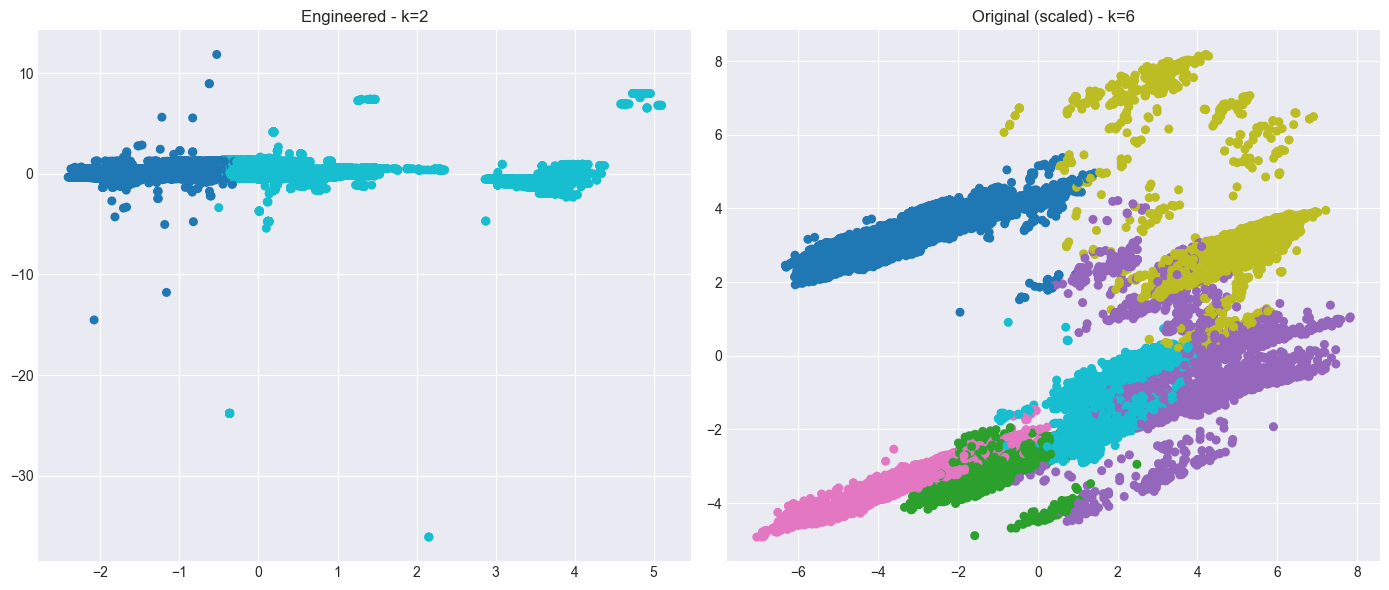

In [7]:
from sklearn.decomposition import PCA

# Choose k to visualize (best by ARI)
k_vis_eng = int(best_eng_ari[0])
k_vis_orig = int(best_orig_ari[0])

pca = PCA(n_components=2, random_state=42)
X_eng_2d = pca.fit_transform(X_eng)
X_orig_2d = pca.fit_transform(X_orig_scaled)

# Fit KMeans for both datasets with chosen k
model_eng = KMeans(n_clusters=k_vis_eng, random_state=42)
model_eng.fit(X_eng)
labels_eng = model_eng.labels_

model_orig = KMeans(n_clusters=k_vis_orig, random_state=42)
model_orig.fit(X_orig_scaled)
labels_orig = model_orig.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_eng_2d[:,0], X_eng_2d[:,1], c=labels_eng, cmap='tab10', s=30)
axes[0].set_title(f'Engineered - k={k_vis_eng}')
axes[1].scatter(X_orig_2d[:,0], X_orig_2d[:,1], c=labels_orig, cmap='tab10', s=30)
axes[1].set_title(f'Original (scaled) - k={k_vis_orig}')
plt.tight_layout()
plt.show()

## test init='random' vs k-means++

Init method comparison results (Engineered dataset):


,init,k,ARI_mean,ARI_std,silhouette_mean,silhouette_std,inertia_mean,inertia_std
0,random,2,0.208169,0.104081,0.403091,0.195782,116094.344548,5700.511847
1,random,3,0.171987,0.093784,0.364578,0.120692,96795.342343,8022.682376
2,random,4,0.211808,0.025783,0.390111,0.012320,71192.996937,2020.189977
3,random,5,0.163583,0.039576,0.382221,0.008325,62633.605711,2323.325492
4,k-means++,2,0.104203,0.127613,0.612747,0.279515,115085.266174,5502.541900
5,k-means++,3,0.121635,0.104113,0.407990,0.159631,95087.334077,6303.753858
6,k-means++,4,0.186835,0.049433,0.364016,0.045790,72027.641429,11640.955006
7,k-means++,5,0.166369,0.042467,0.379449,0.014584,61185.503229,4904.490188


Init method comparison results (Engineered dataset):


,init,k,ARI_mean,ARI_std,silhouette_mean,silhouette_std,inertia_mean,inertia_std,DBI_mean,DBI_std,CH_mean,CH_std,Dunn_mean,Dunn_std
0,random,2,0.208169,0.104081,0.403091,0.195782,116094.344548,5700.511847,1.131085,0.409493,6461.495099,1595.725810,0.036186,0.071077
1,random,3,0.171987,0.093784,0.364578,0.120692,96795.342343,8022.682376,1.016159,0.317106,6815.785503,1861.239304,0.013124,0.025029
2,random,4,0.211808,0.025783,0.390111,0.012320,71192.996937,2020.189977,0.863412,0.088021,9460.906969,528.215884,0.000620,0.000363
3,random,5,0.163583,0.039576,0.382221,0.008325,62633.605711,2323.325492,0.879376,0.082550,9045.445510,591.739054,0.000556,0.000132
4,k-means++,2,0.104203,0.127613,0.612747,0.279515,115085.266174,5502.541900,0.730135,0.526303,6769.759312,1703.266412,0.396788,0.567103
5,k-means++,3,0.121635,0.104113,0.407990,0.159631,95087.334077,6303.753858,1.099120,0.457775,7131.786775,1434.256208,0.035854,0.043940
6,k-means++,4,0.186835,0.049433,0.364016,0.045790,72027.641429,11640.955006,1.006483,0.237998,9662.051027,2714.296154,0.001036,0.000548
7,k-means++,5,0.166369,0.042467,0.379449,0.014584,61185.503229,4904.490188,0.898364,0.133031,9516.138551,1385.771345,0.001213,0.001062


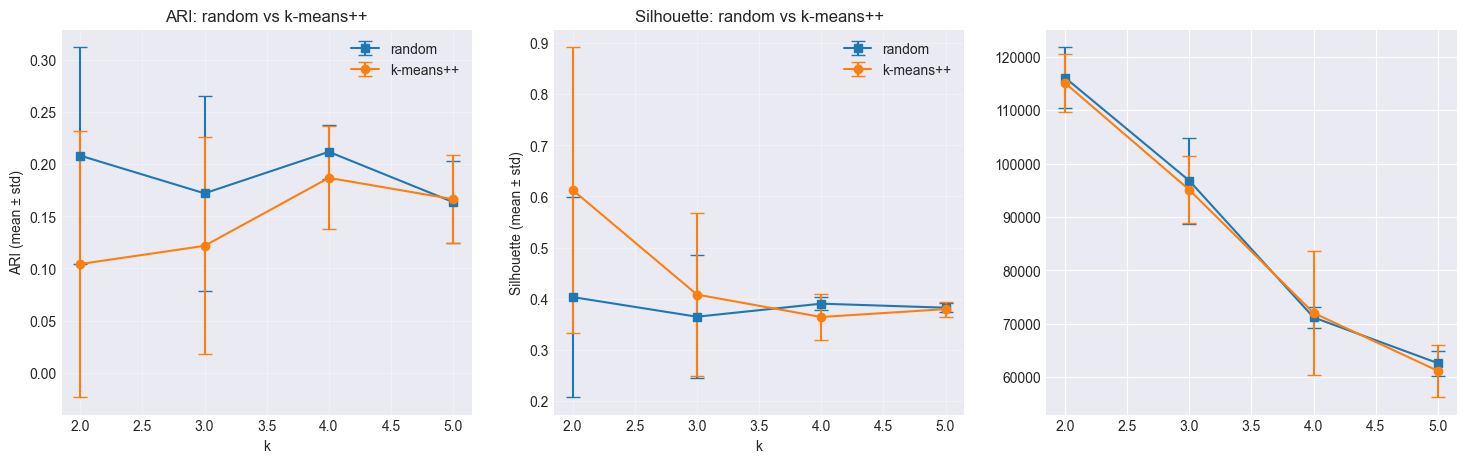

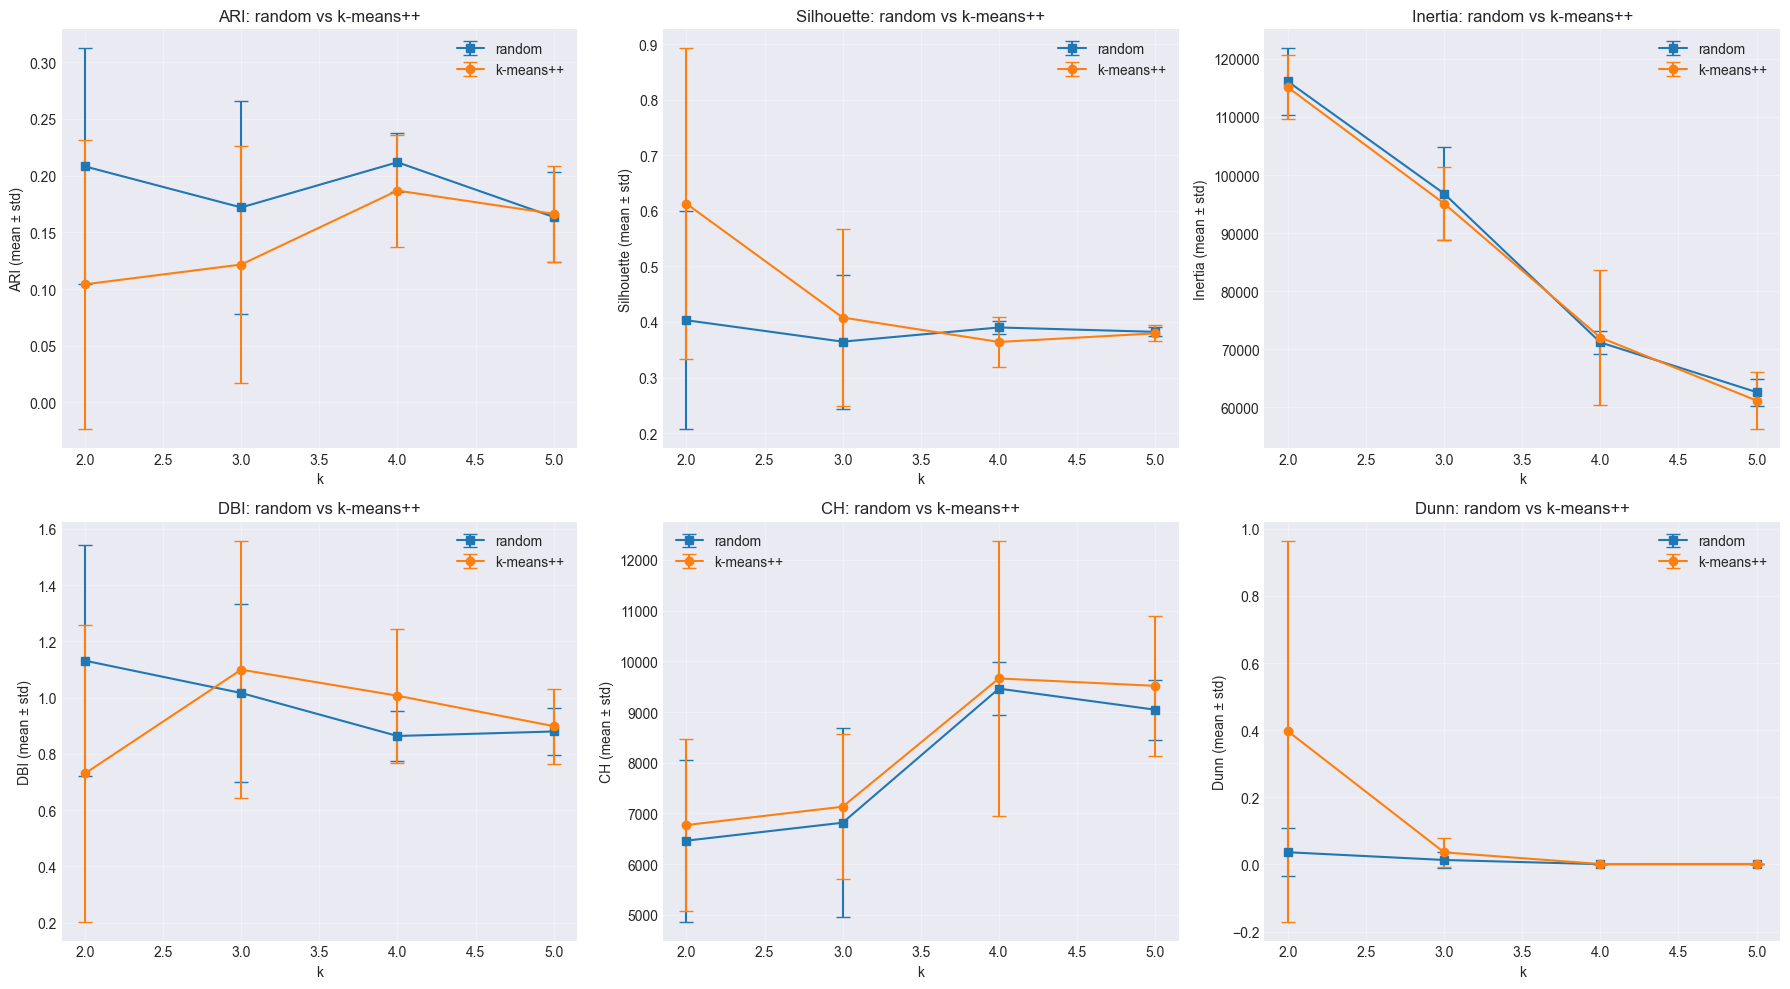

✅ Init method comparison complete: k-means++ typically shows better consistency and convergence


In [8]:
# Compare init methods: 'random' vs 'k-means++'
# We'll test both on the engineered dataset for a few k values and compare stability & metrics

init_methods = ['random', 'k-means++']
k_test = [2, 3, 4, 5]
n_runs = 5  # multiple runs to assess stability

comparison_results = []

for init_method in init_methods:
    for k in k_test:
        run_ari = []
        run_sil = []
        run_inertia = []
        
        for run in range(n_runs):
            model = KMeans(n_clusters=k, init=init_method, random_state=42+run)
            model.fit(X_eng)
            labels = model.labels_
            
            ari = adjusted_rand_score(y_eng, labels)
            run_ari.append(ari)
            run_inertia.append(float(model.inertia_))
            
            unique_clusters = np.unique(labels)
            if len(unique_clusters) >= 2:
                sil = silhouette_score(X_eng, labels, metric='euclidean')
                run_sil.append(sil)
            else:
                run_sil.append(np.nan)
        
        comparison_results.append({
            'init': init_method,
            'k': k,
            'ARI_mean': np.mean(run_ari),
            'ARI_std': np.std(run_ari),
            'silhouette_mean': np.nanmean(run_sil),
            'silhouette_std': np.nanstd(run_sil),
            'inertia_mean': np.mean(run_inertia),
            'inertia_std': np.std(run_inertia)
        })

df_comparison = pd.DataFrame(comparison_results)
print('Init method comparison results (Engineered dataset):')
display(df_comparison)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for init_method in init_methods:
    df_sub = df_comparison[df_comparison['init'] == init_method]
    marker = 'o' if init_method == 'k-means++' else 's'
    
    axes[0].errorbar(df_sub['k'], df_sub['ARI_mean'], yerr=df_sub['ARI_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[1].errorbar(df_sub['k'], df_sub['silhouette_mean'], yerr=df_sub['silhouette_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[2].errorbar(df_sub['k'], df_sub['inertia_mean'], yerr=df_sub['inertia_std'], 
                     marker=marker, label=init_method, capsize=5)

axes[0].set_title('ARI: random vs k-means++')
axes[0].set_xlabel('k')
axes[0].set_ylabel('ARI (mean ± std)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Silhouette: random vs k-means++')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette (mean ± std)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Compare init methods: 'random' vs 'k-means++'
# We'll test both on the engineered dataset for a few k values and compare stability & metrics

init_methods = ['random', 'k-means++']
k_test = [2, 3, 4, 5]
n_runs = 5  # multiple runs to assess stability

comparison_results = []

for init_method in init_methods:
    for k in k_test:
        run_ari = []
        run_sil = []
        run_inertia = []
        run_dbi = []
        run_ch = []
        run_dunn = []
        
        for run in range(n_runs):
            model = KMeans(n_clusters=k, init=init_method, random_state=42+run)
            model.fit(X_eng)
            labels = model.labels_
            
            ari = adjusted_rand_score(y_eng, labels)
            run_ari.append(ari)
            run_inertia.append(float(model.inertia_))
            
            unique_clusters = np.unique(labels)
            if len(unique_clusters) >= 2:
                sil = silhouette_score(X_eng, labels, metric='euclidean')
                run_sil.append(sil)
                try:
                    dbi_val = davies_bouldin_score(X_eng, labels)
                    ch_val = calinski_harabasz_score(X_eng, labels)
                except Exception:
                    dbi_val = np.nan
                    ch_val = np.nan
                run_dbi.append(dbi_val)
                run_ch.append(ch_val)
                # Use sampling for Dunn index to avoid memory issues with large datasets
                if len(X_eng) > 5000:
                    sample_idx = np.random.choice(len(X_eng), 5000, replace=False)
                    dunn_val = compute_dunn_index(X_eng[sample_idx], labels[sample_idx])
                else:
                    dunn_val = compute_dunn_index(X_eng, labels)
                run_dunn.append(dunn_val)
            else:
                run_sil.append(np.nan)
                run_dbi.append(np.nan)
                run_ch.append(np.nan)
                run_dunn.append(np.nan)
        
        comparison_results.append({
            'init': init_method,
            'k': k,
            'ARI_mean': np.mean(run_ari),
            'ARI_std': np.std(run_ari),
            'silhouette_mean': np.nanmean(run_sil),
            'silhouette_std': np.nanstd(run_sil),
            'inertia_mean': np.mean(run_inertia),
            'inertia_std': np.std(run_inertia),
            'DBI_mean': np.nanmean(run_dbi) if len(run_dbi)>0 else np.nan,
            'DBI_std': np.nanstd(run_dbi) if len(run_dbi)>0 else np.nan,
            'CH_mean': np.nanmean(run_ch) if len(run_ch)>0 else np.nan,
            'CH_std': np.nanstd(run_ch) if len(run_ch)>0 else np.nan,
            'Dunn_mean': np.nanmean(run_dunn) if len(run_dunn)>0 else np.nan,
            'Dunn_std': np.nanstd(run_dunn) if len(run_dunn)>0 else np.nan
        })

df_comparison = pd.DataFrame(comparison_results)
print('Init method comparison results (Engineered dataset):')
display(df_comparison)

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for init_method in init_methods:
    df_sub = df_comparison[df_comparison['init'] == init_method]
    marker = 'o' if init_method == 'k-means++' else 's'
    
    axes[0].errorbar(df_sub['k'], df_sub['ARI_mean'], yerr=df_sub['ARI_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[1].errorbar(df_sub['k'], df_sub['silhouette_mean'], yerr=df_sub['silhouette_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[2].errorbar(df_sub['k'], df_sub['inertia_mean'], yerr=df_sub['inertia_std'], 
                     marker=marker, label=init_method, capsize=5)
    axes[3].errorbar(df_sub['k'], df_sub['DBI_mean'], yerr=df_sub['DBI_std'], marker=marker, label=init_method, capsize=5)
    axes[4].errorbar(df_sub['k'], df_sub['CH_mean'], yerr=df_sub['CH_std'], marker=marker, label=init_method, capsize=5)
    axes[5].errorbar(df_sub['k'], df_sub['Dunn_mean'], yerr=df_sub['Dunn_std'], marker=marker, label=init_method, capsize=5)

axes[0].set_title('ARI: random vs k-means++')
axes[0].set_xlabel('k')
axes[0].set_ylabel('ARI (mean ± std)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Silhouette: random vs k-means++')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette (mean ± std)')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].set_title('Inertia: random vs k-means++')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Inertia (mean ± std)')
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].set_title('DBI: random vs k-means++')
axes[3].set_xlabel('k')
axes[3].set_ylabel('DBI (mean ± std)')
axes[3].legend()
axes[3].grid(alpha=0.3)

axes[4].set_title('CH: random vs k-means++')
axes[4].set_xlabel('k')
axes[4].set_ylabel('CH (mean ± std)')
axes[4].legend()
axes[4].grid(alpha=0.3)

axes[5].set_title('Dunn: random vs k-means++')
axes[5].set_xlabel('k')
axes[5].set_ylabel('Dunn (mean ± std)')
axes[5].legend()
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Init method comparison complete: k-means++ typically shows better consistency and convergence')

## Geographic Analysis for k=2, k=3, k=5

This section visualizes clustering results geographically for specific k values to understand:
- **k=2**: North vs South split (fire risk zones)
- **k=3**: More granular regional patterns
- **k=5**: Detailed geographic clustering

The analysis shows how clusters map to geographic regions and correlate with actual fire occurrence.

In [11]:
# =============================================================================
# GEOGRAPHIC ANALYSIS FOR k=2, k=3, k=5
# =============================================================================
# Load coordinates for geographic visualization (use df_orig which already has longitude/latitude)
coords_eng = df_orig[['longitude', 'latitude']].values

# Analyze multiple k values
k_values_analysis = [2, 3, 5]
results_analysis = {}

print("="*80)
print("GEOGRAPHIC CLUSTERING ANALYSIS - K-MEANS")
print("="*80)

for k in k_values_analysis:
    print(f"\n{'='*40}")
    print(f"K = {k}")
    print(f"{'='*40}")
    
    # Fit KMeans
    model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    model.fit(X_eng)
    labels = model.labels_
    
    # Store results
    # Note: Use cluster_centers_ if available, otherwise store None
    centroids = getattr(model, 'cluster_centers_', getattr(model, 'centroids', None))
    results_analysis[k] = {
        'labels': labels,
        'centroids': centroids,
        'inertia': model.inertia_
    }
    
    # Compute metrics
    ari = adjusted_rand_score(y_eng, labels)
    sil = silhouette_score(X_eng, labels)
    
    print(f"ARI: {ari:.4f}")
    print(f"Silhouette: {sil:.4f}")
    print(f"Inertia: {model.inertia_:.2f}")
    
    # Cluster statistics
    print(f"\nCluster distribution:")
    for c in range(k):
        mask = labels == c
        n_points = mask.sum()
        n_fire = (y_eng[mask] == 1).sum()
        n_no_fire = (y_eng[mask] == 0).sum()
        fire_pct = 100 * n_fire / n_points if n_points > 0 else 0
        
        # Geographic info
        lat_mean = coords_eng[mask, 1].mean()
        lon_mean = coords_eng[mask, 0].mean()
        lat_min, lat_max = coords_eng[mask, 1].min(), coords_eng[mask, 1].max()
        
        print(f"  Cluster {c}: {n_points} pts ({100*n_points/len(labels):.1f}%)")
        print(f"    Fire: {n_fire} ({fire_pct:.1f}%) | No-Fire: {n_no_fire} ({100-fire_pct:.1f}%)")
        print(f"    Lat: [{lat_min:.2f}, {lat_max:.2f}], mean={lat_mean:.2f}")

print("\n" + "="*80)

GEOGRAPHIC CLUSTERING ANALYSIS - K-MEANS

K = 2
ARI: 0.2605
Silhouette: 0.3035
Inertia: 113240.27

Cluster distribution:
  Cluster 0: 9600 pts (33.8%)
    Fire: 1172 (12.2%) | No-Fire: 8428 (87.8%)
    Lat: [19.01, 35.06], mean=26.20
  Cluster 1: 18832 pts (66.2%)
    Fire: 13044 (69.3%) | No-Fire: 5788 (30.7%)
    Lat: [25.67, 37.32], mean=32.30

K = 3
ARI: 0.1742
Silhouette: 0.2630
Inertia: 102109.89

Cluster distribution:
  Cluster 0: 9074 pts (31.9%)
    Fire: 1117 (12.3%) | No-Fire: 7957 (87.7%)
    Lat: [19.01, 32.33], mean=25.95
  Cluster 1: 9742 pts (34.3%)
    Fire: 6410 (65.8%) | No-Fire: 3332 (34.2%)
    Lat: [27.56, 37.08], mean=33.46
  Cluster 2: 9616 pts (33.8%)
    Fire: 6689 (69.6%) | No-Fire: 2927 (30.4%)
    Lat: [23.44, 37.32], mean=31.03

K = 5
ARI: 0.1354
Silhouette: 0.3803
Inertia: 66558.74

Cluster distribution:
  Cluster 0: 5153 pts (18.1%)
    Fire: 882 (17.1%) | No-Fire: 4271 (82.9%)
    Lat: [22.17, 35.62], mean=28.12
  Cluster 1: 13408 pts (47.2%)
    Fire: 

### K=2: North vs South Analysis

With k=2, we expect to see a geographic split between:
- **Northern regions** (Mediterranean coast): Higher vegetation, higher fire risk
- **Southern regions** (Sahara): Desert, lower fire occurrence

This visualization shows if K-Means captures the North-South fire risk gradient.

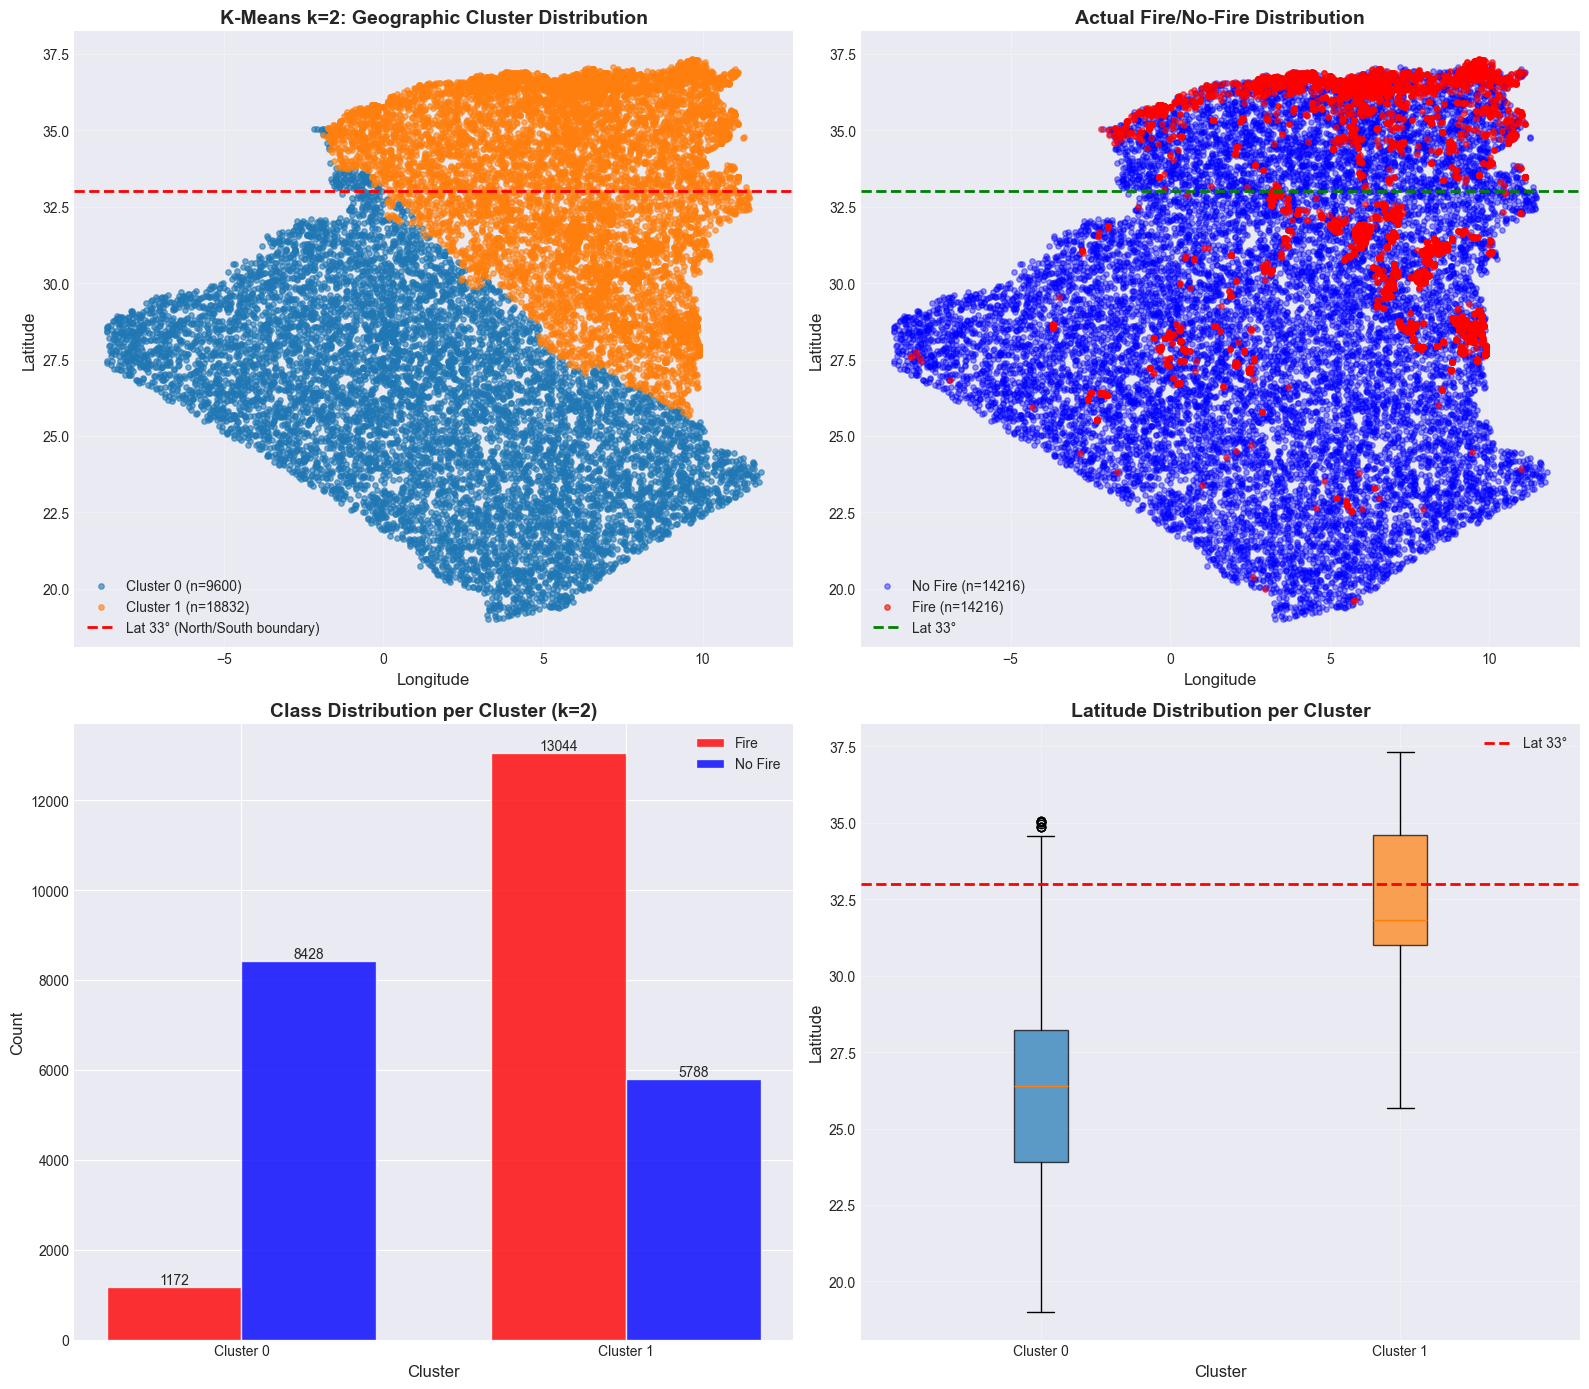


K=2 ANALYSIS SUMMARY

Cluster 0 -> SOUTH (Sahara)
  Mean latitude: 26.20°
  Fire percentage: 12.2%
  Interpretation: Lower fire risk zone

Cluster 1 -> SOUTH (Sahara)
  Mean latitude: 32.30°
  Fire percentage: 69.3%
  Interpretation: Higher fire risk zone


In [12]:
# =============================================================================
# K=2 GEOGRAPHIC VISUALIZATION
# =============================================================================
k = 2
labels_k2 = results_analysis[k]['labels']

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: Geographic map with clusters
ax1 = axes[0, 0]
colors = ['#1f77b4', '#ff7f0e']  # Blue, Orange
for c in range(k):
    mask = labels_k2 == c
    ax1.scatter(coords_eng[mask, 0], coords_eng[mask, 1], 
                c=colors[c], s=15, alpha=0.6, label=f'Cluster {c} (n={mask.sum()})')
ax1.axhline(y=33, color='red', linestyle='--', linewidth=2, label='Lat 33° (North/South boundary)')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title(f'K-Means k={k}: Geographic Cluster Distribution', fontsize=14, fontweight='bold')
ax1.legend(loc='lower left')
ax1.grid(alpha=0.3)

# Plot 2: Actual class distribution (Fire vs No-Fire)
ax2 = axes[0, 1]
fire_mask = y_eng == 1
no_fire_mask = y_eng == 0
ax2.scatter(coords_eng[no_fire_mask, 0], coords_eng[no_fire_mask, 1], 
            c='blue', s=15, alpha=0.4, label=f'No Fire (n={no_fire_mask.sum()})')
ax2.scatter(coords_eng[fire_mask, 0], coords_eng[fire_mask, 1], 
            c='red', s=15, alpha=0.6, label=f'Fire (n={fire_mask.sum()})')
ax2.axhline(y=33, color='green', linestyle='--', linewidth=2, label='Lat 33°')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title('Actual Fire/No-Fire Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

# Plot 3: Class distribution per cluster (bar chart)
ax3 = axes[1, 0]
cluster_class_data = []
for c in range(k):
    mask = labels_k2 == c
    n_fire = (y_eng[mask] == 1).sum()
    n_no_fire = (y_eng[mask] == 0).sum()
    cluster_class_data.append({'Cluster': f'Cluster {c}', 'Fire': n_fire, 'No Fire': n_no_fire})

df_cluster_class = pd.DataFrame(cluster_class_data)
x = np.arange(k)
width = 0.35
bars1 = ax3.bar(x - width/2, df_cluster_class['Fire'], width, label='Fire', color='red', alpha=0.8)
bars2 = ax3.bar(x + width/2, df_cluster_class['No Fire'], width, label='No Fire', color='blue', alpha=0.8)
ax3.set_xlabel('Cluster', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title(f'Class Distribution per Cluster (k={k})', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Cluster {c}' for c in range(k)])
ax3.legend()
for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(bar.get_height())}', 
             ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(bar.get_height())}', 
             ha='center', va='bottom', fontsize=10)

# Plot 4: Latitude distribution per cluster (box plot)
ax4 = axes[1, 1]
lat_per_cluster = [coords_eng[labels_k2 == c, 1] for c in range(k)]
bp = ax4.boxplot(lat_per_cluster, labels=[f'Cluster {c}' for c in range(k)], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.axhline(y=33, color='red', linestyle='--', linewidth=2, label='Lat 33°')
ax4.set_xlabel('Cluster', fontsize=12)
ax4.set_ylabel('Latitude', fontsize=12)
ax4.set_title('Latitude Distribution per Cluster', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics for k=2
print("\n" + "="*60)
print("K=2 ANALYSIS SUMMARY")
print("="*60)
for c in range(k):
    mask = labels_k2 == c
    lat_mean = coords_eng[mask, 1].mean()
    fire_pct = 100 * (y_eng[mask] == 1).sum() / mask.sum()
    region = "NORTH (Mediterranean)" if lat_mean > 33 else "SOUTH (Sahara)"
    print(f"\nCluster {c} -> {region}")
    print(f"  Mean latitude: {lat_mean:.2f}°")
    print(f"  Fire percentage: {fire_pct:.1f}%")
    print(f"  Interpretation: {'Higher fire risk zone' if fire_pct > 50 else 'Lower fire risk zone'}")

### K=3 and K=5: Regional Pattern Analysis

With more clusters, we can identify more nuanced geographic patterns:
- **k=3**: Potentially separates coastal, interior, and desert regions
- **k=5**: May reveal sub-regions with distinct fire risk profiles

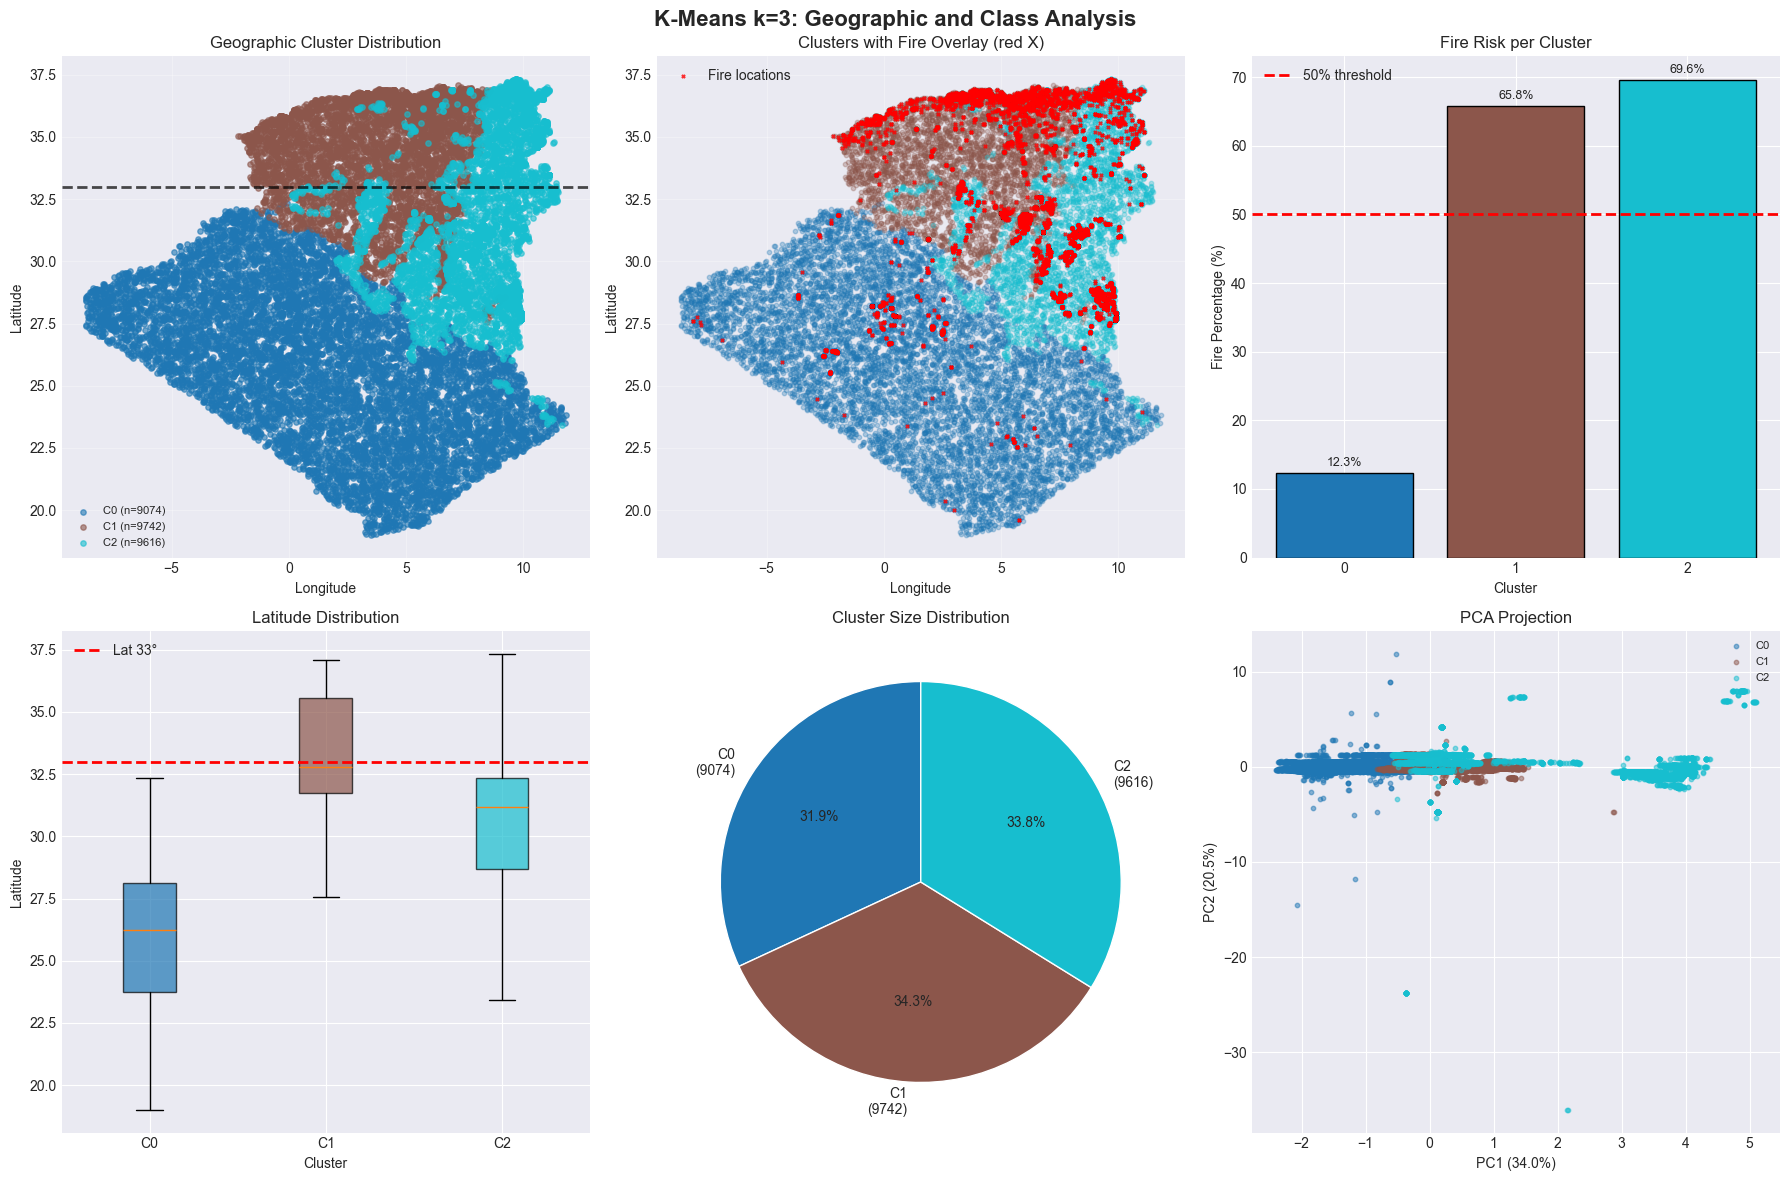


K=3 CLUSTER SUMMARY

Cluster 0:
  Region: SAHARA SOUTH (lat=25.9°, lon=1.2°)
  Size: 9074 points (31.9%)
  Fire risk: 12.3% -> LOW RISK

Cluster 1:
  Region: INTERIOR NORTH (lat=33.5°, lon=4.7°)
  Size: 9742 points (34.3%)
  Fire risk: 65.8% -> HIGH RISK

Cluster 2:
  Region: TRANSITION ZONE (lat=31.0°, lon=8.0°)
  Size: 9616 points (33.8%)
  Fire risk: 69.6% -> HIGH RISK


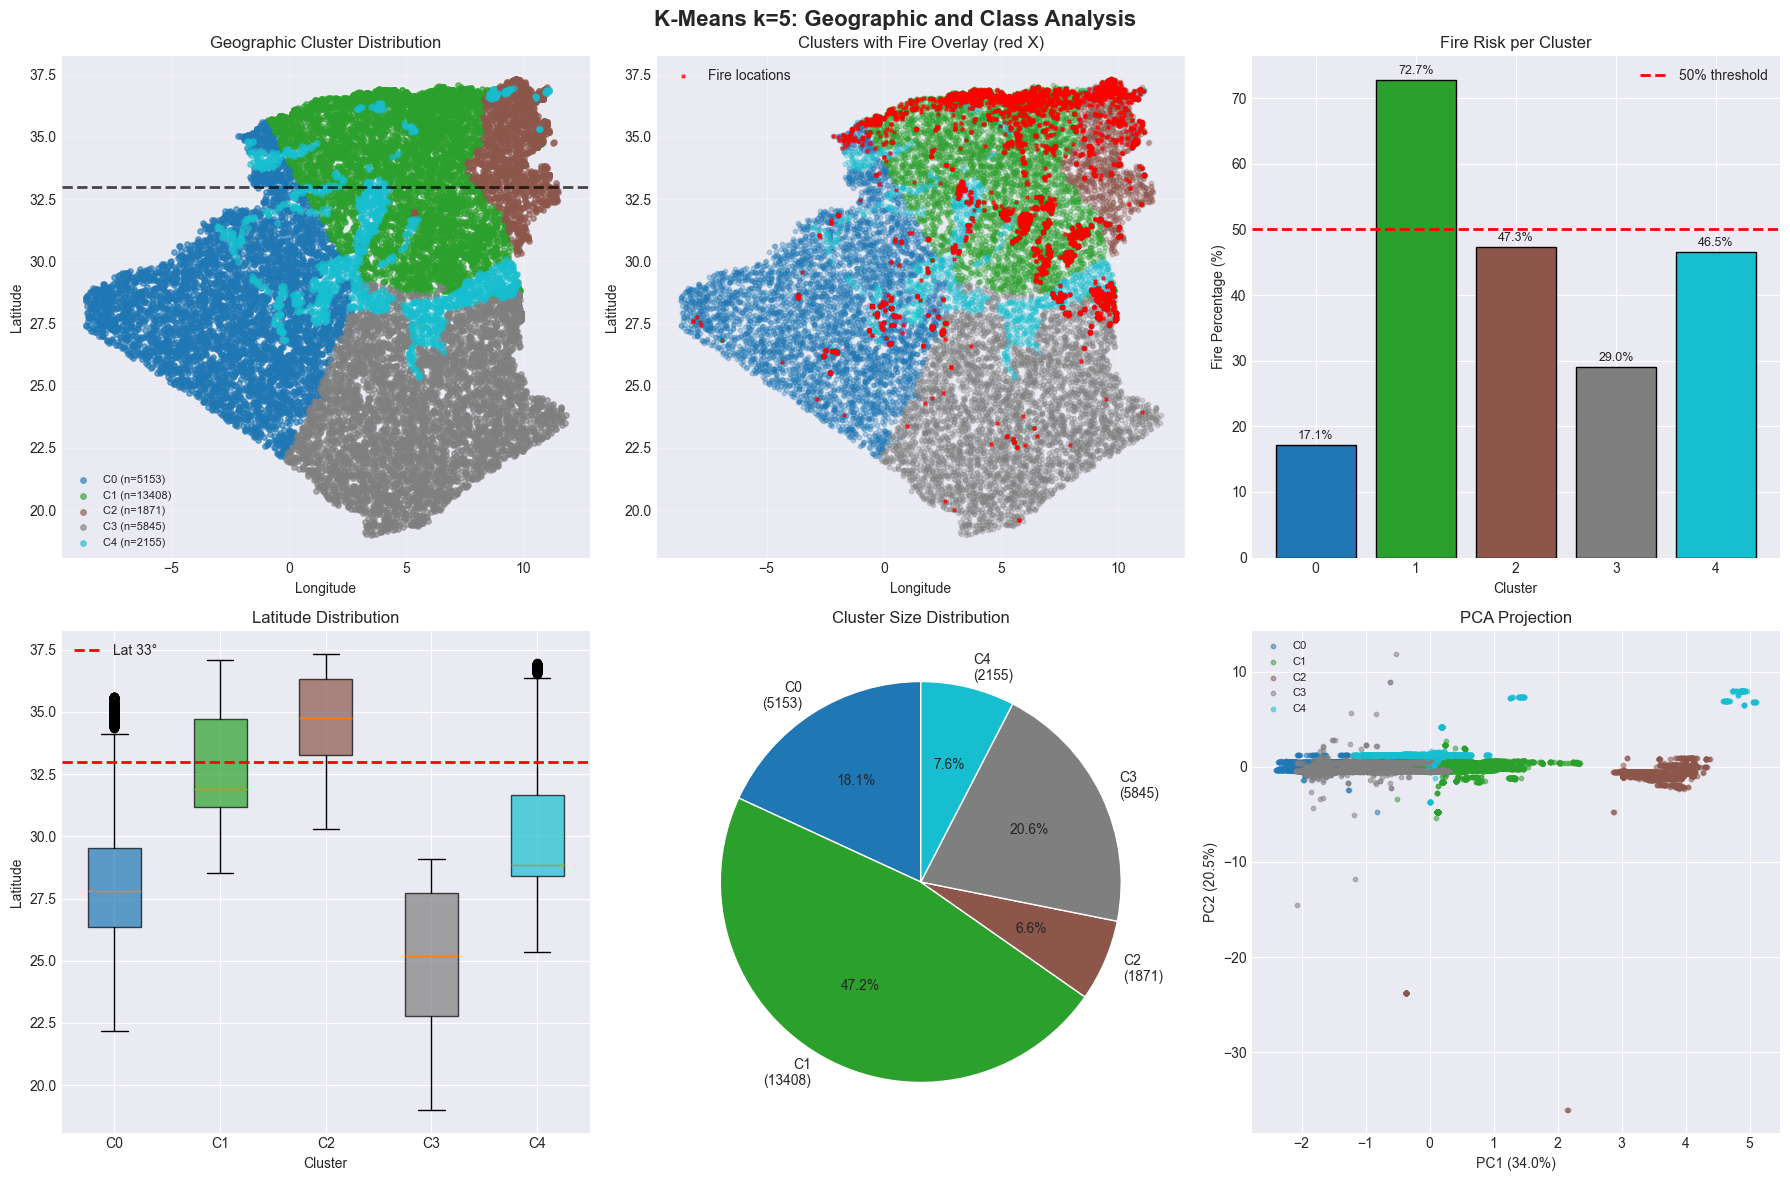


K=5 CLUSTER SUMMARY

Cluster 0:
  Region: SAHARA SOUTH (lat=28.1°, lon=-1.9°)
  Size: 5153 points (18.1%)
  Fire risk: 17.1% -> LOW RISK

Cluster 1:
  Region: TRANSITION ZONE (lat=32.8°, lon=5.7°)
  Size: 13408 points (47.2%)
  Fire risk: 72.7% -> HIGH RISK

Cluster 2:
  Region: INTERIOR NORTH (lat=34.6°, lon=9.6°)
  Size: 1871 points (6.6%)
  Fire risk: 47.3% -> MEDIUM RISK

Cluster 3:
  Region: SAHARA SOUTH (lat=25.0°, lon=6.6°)
  Size: 5845 points (20.6%)
  Fire risk: 29.0% -> LOW RISK

Cluster 4:
  Region: TRANSITION ZONE (lat=30.0°, lon=4.6°)
  Size: 2155 points (7.6%)
  Fire risk: 46.5% -> MEDIUM RISK


In [13]:
# =============================================================================
# K=3 AND K=5 GEOGRAPHIC VISUALIZATION
# =============================================================================

for k in [3, 5]:
    labels_k = results_analysis[k]['labels']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'K-Means k={k}: Geographic and Class Analysis', fontsize=16, fontweight='bold')
    
    # Color palette
    colors = plt.cm.tab10(np.linspace(0, 1, k))
    
    # Plot 1: Geographic map with clusters
    ax1 = axes[0, 0]
    for c in range(k):
        mask = labels_k == c
        ax1.scatter(coords_eng[mask, 0], coords_eng[mask, 1], 
                    c=[colors[c]], s=15, alpha=0.6, label=f'C{c} (n={mask.sum()})')
    ax1.axhline(y=33, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.set_title('Geographic Cluster Distribution')
    ax1.legend(loc='lower left', fontsize=8)
    ax1.grid(alpha=0.3)
    
    # Plot 2: Clusters with fire overlay
    ax2 = axes[0, 1]
    for c in range(k):
        mask = labels_k == c
        ax2.scatter(coords_eng[mask, 0], coords_eng[mask, 1], 
                    c=[colors[c]], s=10, alpha=0.3)
    fire_mask = y_eng == 1
    ax2.scatter(coords_eng[fire_mask, 0], coords_eng[fire_mask, 1], 
                c='red', s=5, alpha=0.8, marker='x', label='Fire locations')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.set_title('Clusters with Fire Overlay (red X)')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Fire percentage per cluster (bar)
    ax3 = axes[0, 2]
    fire_pcts = []
    for c in range(k):
        mask = labels_k == c
        fire_pct = 100 * (y_eng[mask] == 1).sum() / mask.sum() if mask.sum() > 0 else 0
        fire_pcts.append(fire_pct)
    bars = ax3.bar(range(k), fire_pcts, color=colors, edgecolor='black')
    ax3.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('Fire Percentage (%)')
    ax3.set_title('Fire Risk per Cluster')
    ax3.set_xticks(range(k))
    ax3.legend()
    for bar, pct in zip(bars, fire_pcts):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{pct:.1f}%', ha='center', fontsize=9)
    
    # Plot 4: Latitude distribution per cluster
    ax4 = axes[1, 0]
    lat_data = [coords_eng[labels_k == c, 1] for c in range(k)]
    bp = ax4.boxplot(lat_data, labels=[f'C{c}' for c in range(k)], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax4.axhline(y=33, color='red', linestyle='--', linewidth=2, label='Lat 33°')
    ax4.set_xlabel('Cluster')
    ax4.set_ylabel('Latitude')
    ax4.set_title('Latitude Distribution')
    ax4.legend()
    
    # Plot 5: Cluster sizes
    ax5 = axes[1, 1]
    sizes = [np.sum(labels_k == c) for c in range(k)]
    ax5.pie(sizes, labels=[f'C{c}\n({s})' for c, s in enumerate(sizes)], 
            colors=colors, autopct='%1.1f%%', startangle=90)
    ax5.set_title('Cluster Size Distribution')
    
    # Plot 6: PCA 2D visualization
    ax6 = axes[1, 2]
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_eng)
    for c in range(k):
        mask = labels_k == c
        ax6.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[c]], s=10, alpha=0.5, label=f'C{c}')
    ax6.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax6.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax6.set_title('PCA Projection')
    ax6.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"K={k} CLUSTER SUMMARY")
    print(f"{'='*60}")
    for c in range(k):
        mask = labels_k == c
        lat_mean = coords_eng[mask, 1].mean()
        lon_mean = coords_eng[mask, 0].mean()
        fire_pct = fire_pcts[c]
        
        # Determine region
        if lat_mean > 35:
            region = "COASTAL NORTH"
        elif lat_mean > 33:
            region = "INTERIOR NORTH"
        elif lat_mean > 30:
            region = "TRANSITION ZONE"
        else:
            region = "SAHARA SOUTH"
        
        risk_level = "HIGH" if fire_pct > 60 else "MEDIUM" if fire_pct > 40 else "LOW"
        
        print(f"\nCluster {c}:")
        print(f"  Region: {region} (lat={lat_mean:.1f}°, lon={lon_mean:.1f}°)")
        print(f"  Size: {mask.sum()} points ({100*mask.sum()/len(labels_k):.1f}%)")
        print(f"  Fire risk: {fire_pct:.1f}% -> {risk_level} RISK")

### Metrics Comparison Across k Values

Summary table comparing all metrics for k=2, k=3, k=5 to help determine the best clustering.

METRICS COMPARISON: k=2, k=3, k=5


,k,ARI,AMI,Silhouette,Homogeneity,Completeness,Purity,Inertia
0,2,0.2605,0.2389,0.3035,0.2297,0.2490,0.7552,113240.2679
1,3,0.1742,0.1631,0.2630,0.2108,0.1331,0.7406,102109.8859
2,5,0.1354,0.1091,0.3803,0.1620,0.0823,0.7145,66558.7378


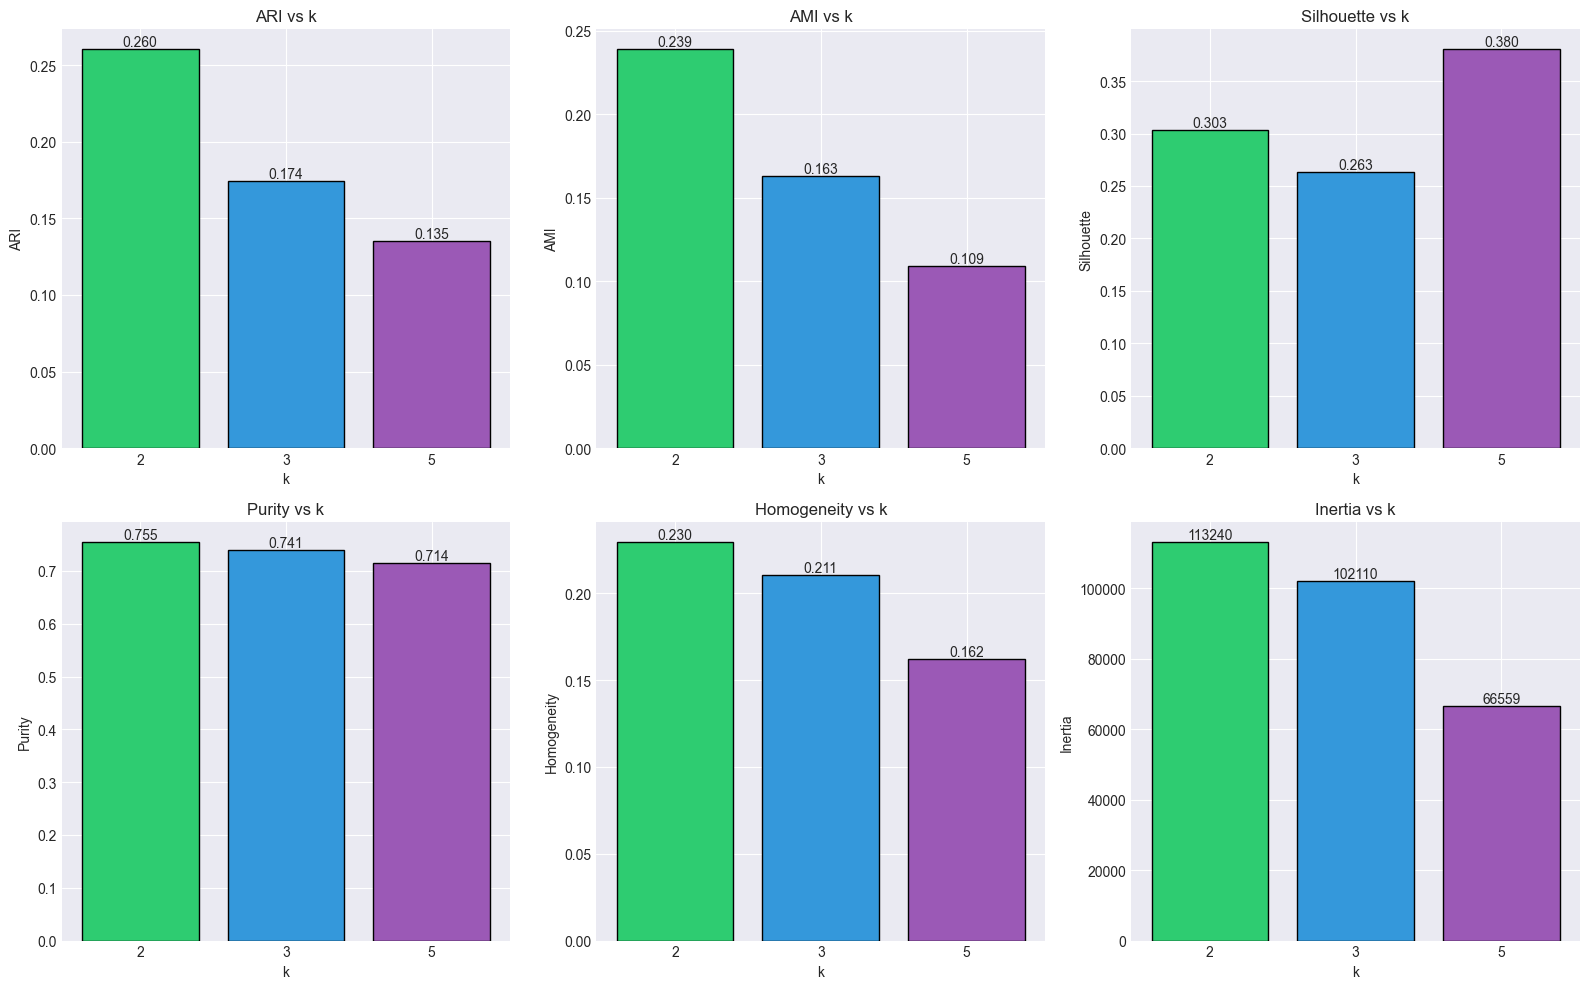


RECOMMENDATION
Best k by ARI: k=2
Best k by Silhouette: k=5

Note: k=2 typically shows North/South fire risk split
      k=3 or k=5 may reveal more nuanced regional patterns


: 

In [ ]:
# =============================================================================
# METRICS COMPARISON: k=2, k=3, k=5
# =============================================================================
comparison_metrics = []

for k in [2, 3, 5]:
    labels_k = results_analysis[k]['labels']
    
    ari = adjusted_rand_score(y_eng, labels_k)
    ami = adjusted_mutual_info_score(y_eng, labels_k)
    sil = silhouette_score(X_eng, labels_k)
    hom = homogeneity_score(y_eng, labels_k)
    comp = completeness_score(y_eng, labels_k)
    
    # Purity
    unique_clusters = np.unique(labels_k)
    cluster_purities = []
    for c in unique_clusters:
        members = y_eng[labels_k == c]
        if len(members) > 0:
            cluster_purities.append(np.bincount(members.astype(int)).max())
    purity = np.sum(cluster_purities) / len(labels_k)
    
    comparison_metrics.append({
        'k': k,
        'ARI': ari,
        'AMI': ami,
        'Silhouette': sil,
        'Homogeneity': hom,
        'Completeness': comp,
        'Purity': purity,
        'Inertia': results_analysis[k]['inertia']
    })

df_comparison = pd.DataFrame(comparison_metrics)

print("="*80)
print("METRICS COMPARISON: k=2, k=3, k=5")
print("="*80)
display(df_comparison.round(4))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

metrics_to_plot = ['ARI', 'AMI', 'Silhouette', 'Purity', 'Homogeneity', 'Inertia']
colors_bar = ['#2ecc71', '#3498db', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(df_comparison['k'].astype(str), df_comparison[metric], color=colors_bar, edgecolor='black')
    ax.set_xlabel('k')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs k')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}' if metric != 'Inertia' else f'{height:.0f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Best k recommendation
print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)
best_ari_k = df_comparison.loc[df_comparison['ARI'].idxmax(), 'k']
best_sil_k = df_comparison.loc[df_comparison['Silhouette'].idxmax(), 'k']
print(f"Best k by ARI: k={best_ari_k}")
print(f"Best k by Silhouette: k={best_sil_k}")
print(f"\nNote: k=2 typically shows North/South fire risk split")
print(f"      k=3 or k=5 may reveal more nuanced regional patterns")

### Interpretation Guidelines (To be filled after running)

After executing the cells above, observe:

**For k=2:**
- [ ] Does one cluster correspond to Northern regions (lat > 33°)?
- [ ] Does the Northern cluster have higher fire percentage?
- [ ] Is there clear geographic separation between clusters?

**For k=3:**
- [ ] Do clusters separate coastal, interior, and desert regions?
- [ ] Which cluster has the highest fire risk?
- [ ] Are the fire percentages meaningful (>60% high risk, <40% low risk)?

**For k=5:**
- [ ] Do clusters reveal sub-regional patterns?
- [ ] Are small clusters outliers or meaningful zones?
- [ ] Does increased k improve or worsen clustering metrics?

**General observations:**
- Compare ARI, Silhouette, Purity across k values
- Note which k best separates fire/non-fire classes
- Document any unexpected geographic patterns